## 1. Installation
First things first, let’s install all necessary dependencies. You can do this by running the following command in your terminal:

In [1]:
!pip install tensorflow numpy matplotlib scikit-learn pandas opencv-python

## 2. Import all necessary libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPUs available: []


## 3. Configuration & Data Loading

In [3]:
# Paths (notebook lives in 0_DL/src/, data is in 0_DL/)
TRAIN_DIR = '../train'
TEST_DIR  = '../test'
TEST_CSV  = '../test.csv'

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 7
SEED = 42

# Labels are assigned alphabetically by folder name
CLASS_NAMES = [
    'Black_spiny_tailed_iguana',  # 0
    'Brown_anole',                # 1
    'Cuban_knight_anole',         # 2
    'Desert_iguana',              # 3
    'Green_anole',                # 4
    'Green_iguana',               # 5
    'Lesser_Antillean_iguana',    # 6
]

In [4]:
# Load train (80%) and validation (20%) datasets from the class-labelled folder structure
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)

val_ds = image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)

print("Class names:", train_ds.class_names)
print("Train batches:", len(train_ds), " | Val batches:", len(val_ds))

# Cache and prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1334 files belonging to 7 classes.
Using 1068 files for training.
Found 1334 files belonging to 7 classes.
Using 266 files for validation.
Class names: ['Black_spiny_tailed_iguana', 'Brown_anole', 'Cuban_knight_anole', 'Desert_iguana', 'Green_anole', 'Green_iguana', 'Lesser_Antillean_iguana']
Train batches: 34  | Val batches: 9


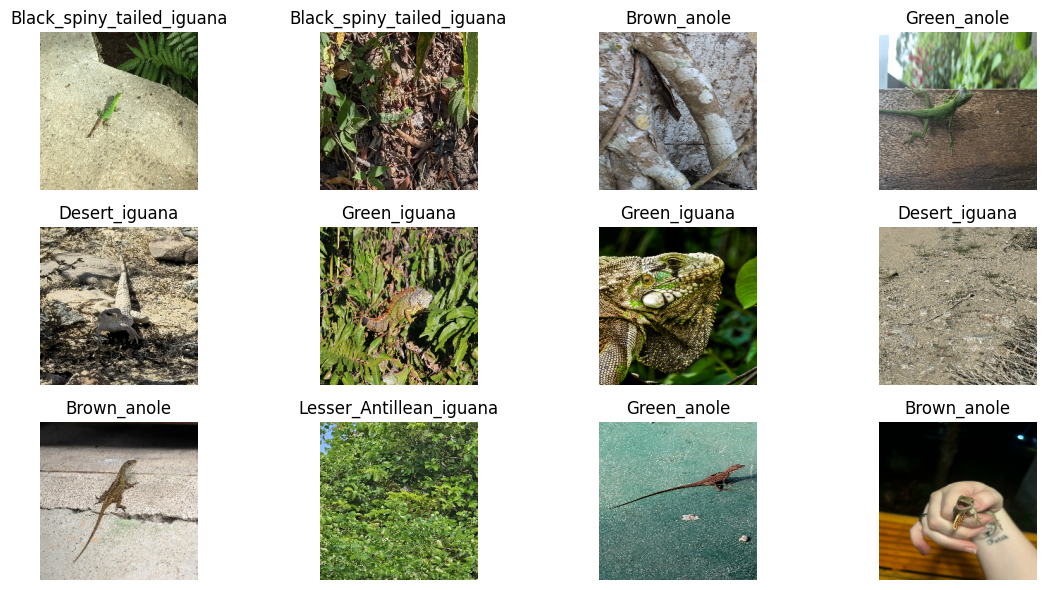

In [5]:
# Show a sample of training images
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(CLASS_NAMES[labels[i]])
        plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Build Model (Transfer Learning — MobileNetV2)

In [6]:
# Data augmentation applied only during training
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
], name='augmentation')

# Rescale pixels to [-1, 1] as expected by MobileNetV2
preprocess = layers.Rescaling(1./127.5, offset=-1, name='rescaling')

# Frozen MobileNetV2 backbone (pretrained on ImageNet)
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Train Model

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 636ms/step - accuracy: 0.2397 - loss: 2.0678 - val_accuracy: 0.3910 - val_loss: 1.6315 - learning_rate: 0.0010
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 599ms/step - accuracy: 0.4195 - loss: 1.5492 - val_accuracy: 0.4774 - val_loss: 1.4474 - learning_rate: 0.0010
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 577ms/step - accuracy: 0.4682 - loss: 1.3682 - val_accuracy: 0.5226 - val_loss: 1.3485 - learning_rate: 0.0010
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 579ms/step - accuracy: 0.5187 - loss: 1.2407 - val_accuracy: 0.5188 - val_loss: 1.3054 - learning_rate: 0.0010
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 666ms/step - accuracy: 0.5478 - loss: 1.2028 - val_accuracy: 0.5414 - val_loss: 1.2636 - learning_rate: 0.0010
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 635ms/step - accuracy: 0.5843 - loss: 1.1132 - val_accuracy: 0.5526 - val_loss: 1.2474 - learning_rate: 0.0010
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 579ms/step - accuracy: 0.5721 - loss: 1.

## 6. Evaluate — Training Curves & Confusion Matrix

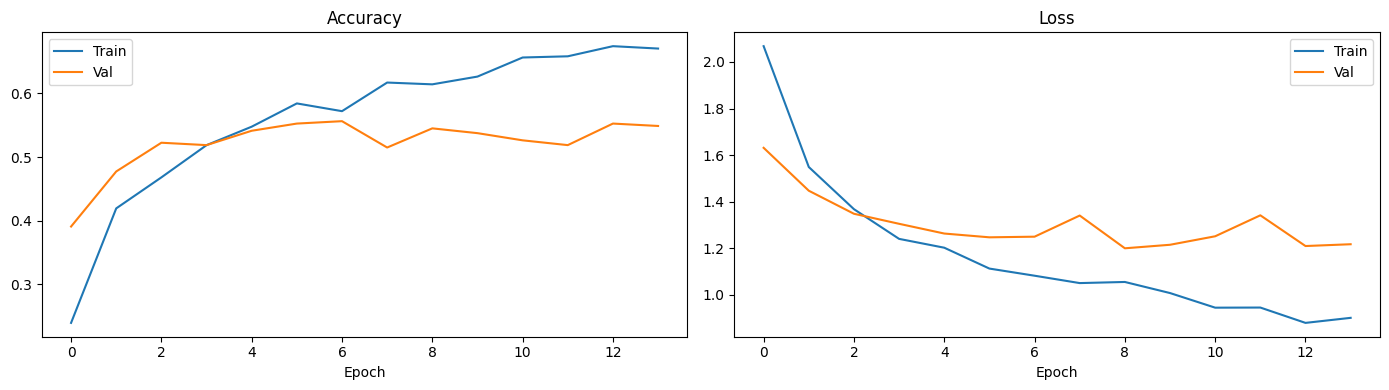

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

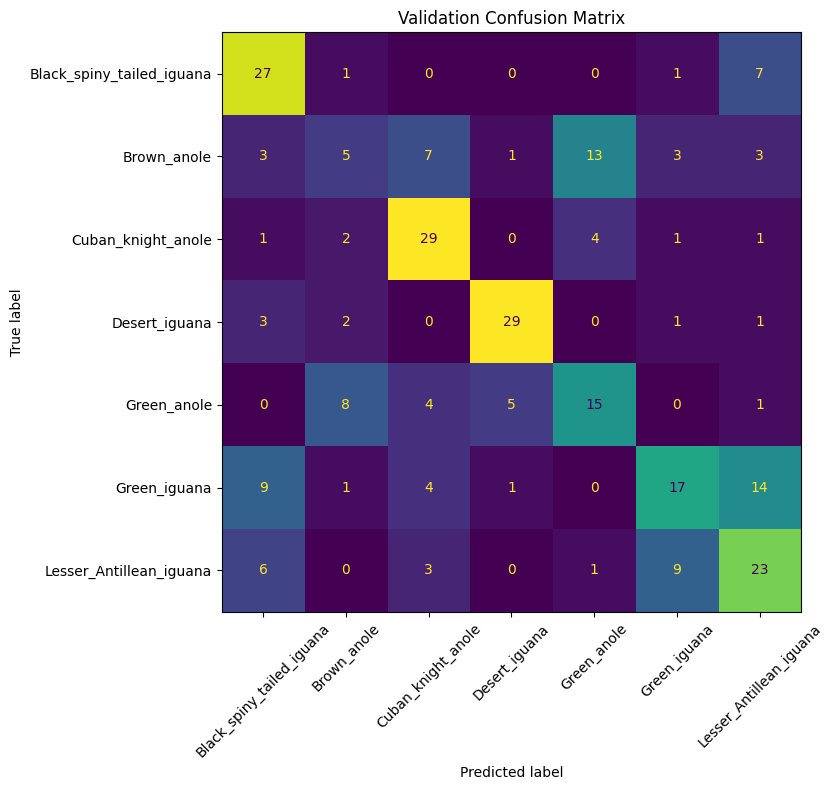


Validation accuracy: 0.5451


In [9]:
# Confusion matrix on the validation set
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Validation Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"\nValidation accuracy: {np.sum(np.array(y_true)==np.array(y_pred))/len(y_true):.4f}")

## 7. Predict on Test Set & Generate Submission

In [10]:
# Load test IDs from test.csv
test_df = pd.read_csv(TEST_CSV)
test_ids = test_df['id'].tolist()

# Load each test image, preprocess, and predict
predictions = []
for img_id in test_ids:
    img_path = os.path.join(TEST_DIR, f'{img_id}.jpg')
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)           # (1, H, W, 3)
    pred = model.predict(img_array, verbose=0)
    predictions.append(int(np.argmax(pred, axis=1)[0]))

submission = pd.DataFrame({'id': test_ids, 'label': predictions})
submission.to_csv('../submission.csv', index=False)
print(f"Saved submission.csv with {len(submission)} predictions")
submission.head(10)

Saved submission.csv with 326 predictions


,id,label
0,1,6
1,2,5
2,3,0
3,4,5
4,5,0
5,6,6
6,7,6
7,8,4
8,9,4
9,10,1
